In [4]:
import json
import matplotlib.pyplot as plt

In [5]:
states_str = open("log/midtrain_running_states.json").readline()
history = states_str.replace("\'", "\"")
history = json.loads(history)
history[-3:]

[{'loss': 2.6516,
  'grad_norm': 0.48321768641471863,
  'learning_rate': 3.2992621606942052e-12,
  'epoch': 0.9999198782148866,
  'step': 6240},
 {'train_runtime': 7857.5823,
  'train_samples_per_second': 101.656,
  'train_steps_per_second': 0.794,
  'total_flos': 4.051662911003689e+17,
  'train_loss': 2.694405018671965,
  'epoch': 0.9999198782148866,
  'step': 6240},
 {'eval_loss': 2.6190621852874756,
  'eval_runtime': 14.1544,
  'eval_samples_per_second': 283.587,
  'eval_steps_per_second': 17.733,
  'epoch': 0.9999198782148866,
  'step': 6240}]

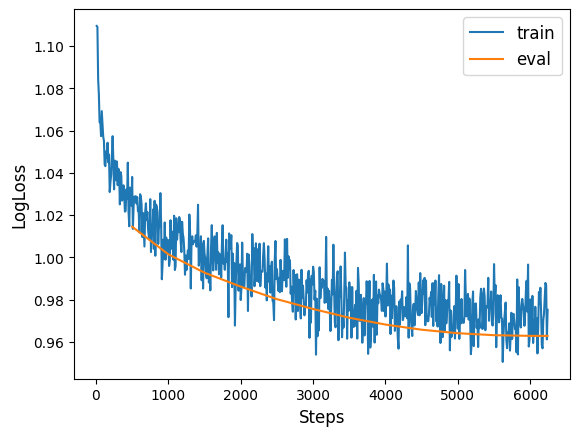

In [6]:
train_steps = [item["step"] for item in history if "loss" in item]
train_loss = [item["loss"] for item in history if "loss" in item]
eval_steps = [item["step"] for item in history if "eval_loss" in item]
eval_loss = [item["eval_loss"] for item in history if "eval_loss" in item]
import numpy as np
train_log_loss = np.log(train_loss)
eval_log_loss = np.log(eval_loss)

plt.plot(train_steps, train_log_loss, label="train")
plt.plot(eval_steps, eval_log_loss, label="eval")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("LogLoss", fontsize=12)
plt.legend(fontsize=12)
plt.show()